In [13]:
using ITensors, ITensorMPS, Plots, Statistics, StatsBase, GLM, DataFrames, Kneedle, SavitzkyGolay


include(joinpath(@__DIR__, "helper_functions.jl"))

system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

Dict{String, Any} with 6 entries:
  "Δ"            => -1.0
  "J"            => -1.0
  "μ"            => 1.0
  "MAX_BOND_DIM" => 1000
  "NUM_SWEEPS"   => 10
  "ACC"          => 1.0e-16

Starting Bond Dimension data collection...
Finished σ = 0.0001
Finished σ = 0.0002
Finished σ = 0.0003
Finished σ = 0.0004
Finished σ = 0.0005
Finished σ = 0.0006
Finished σ = 0.0007
Finished σ = 0.0008
Finished σ = 0.0009
Finished σ = 0.001
Finished σ = 0.0011
Finished σ = 0.0012
Finished σ = 0.0013
Finished σ = 0.0014
Finished σ = 0.0015
Finished σ = 0.0016
Finished σ = 0.0017
Finished σ = 0.0018
Finished σ = 0.0019
Finished σ = 0.002


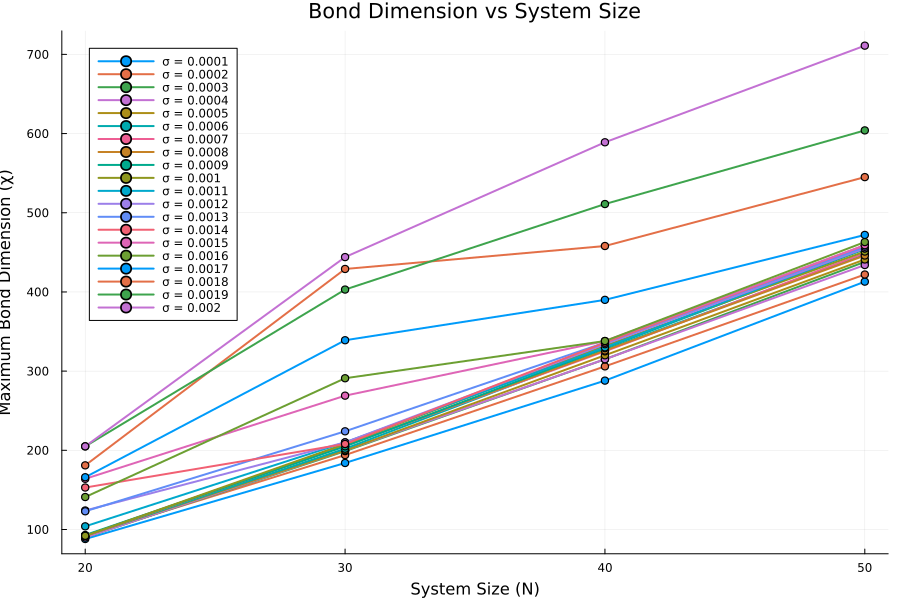

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\bond_dimension_vs_N_all_sigmas.png"

In [14]:


N_vals = 20:10:50
sigma_vals = 0.0001:0.0001:0.002

# Initialise a dictionary to store the bond dimensions
# Key: sigma, Value: List of (N, bond_dimension) tuples
bond_dim_results = Dict{Float64, Vector{Tuple{Int, Int}}}()

println("Starting Bond Dimension data collection...")

for σ in sigma_vals
    bond_dim_results[σ] = []
    
    # We use the system_params from your earlier cells
    filepath_base = extract_filename_from_system_params(system_params)
    MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(σ)_$filepath_base.hd5")
    
    if isfile(MPS_filepath)
        for N in N_vals
            run_params = Dict{String, Any}("N" => N, "σ" => σ)
            
            # Load the latest matching run
            matches = find_runs_by_params(MPS_filepath, run_params; load_psi = true, instance_selection = :latest)
            
            if !isempty(matches)
                psi = matches[1].psi
                # Extract the maximum bond dimension
                bd = maxlinkdim(psi)
                
                push!(bond_dim_results[σ], (N, bd))
            end
        end
        println("Finished σ = $σ")
    else
        println("File not found for σ = $σ: $MPS_filepath")
    end
end

p_bd = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Maximum Bond Dimension (χ)",
    legend = :topleft,
    grid = true,
    size = (900, 600)
)

for σ in sort(collect(keys(bond_dim_results)))
    data = bond_dim_results[σ]
    if !isempty(data)
        # Ensure N values are sorted for the line plot
        sort!(data, by = x -> x[1])
        x_vals = [d[1] for d in data]
        y_vals = [d[2] for d in data]
        
        plot!(p_bd, x_vals, y_vals, label="σ = $σ", marker=:circle, linewidth=2)
    end
end

display(p_bd)
savefig(p_bd, joinpath(@__DIR__, "images", "bond_dimension_vs_N_all_sigmas.png"))

In [15]:


run_params_cln = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.00
)

run_params_dis = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.0001
)

filepath = extract_filename_from_system_params(system_params)
MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(run_params_dis["σ"])_$filepath.hd5")
matches_clean = find_runs_by_params(MPS_filepath, run_params_cln, load_psi = true, instance_selection =:latest)
matches_disordered = find_runs_by_params(MPS_filepath, run_params_dis; load_psi = true, instance_selection =:latest)

psi_clean = matches_clean[1].psi
psi_disordered = matches_disordered[1].psi

spec_clean = get_squared_sorted_schmidt_spectrum_from_mps(psi_clean)
spec_disordered = get_squared_sorted_schmidt_spectrum_from_mps(psi_disordered)

288-element Vector{Float64}:
 0.2476286785444157
 0.20465186064464125
 0.2046518606311878
 0.11511677318520878
 0.11511677316546572
 0.043594581764167174
 0.04359458175261027
 0.010898667879114584
 0.010898667869544
 0.0017437914764259523
 0.0017437914744460176
 0.00017029268728197157
 0.00017029268472459086
 ⋮
 6.857623233892802e-17
 6.841197190945132e-17
 6.497654423100544e-17
 6.44382367385411e-17
 6.059766431195942e-17
 5.917322366919071e-17
 4.9100737877984215e-17
 4.8830643851331776e-17
 3.814119712660896e-17
 3.8116235819944025e-17
 3.190891405226908e-17
 3.189935820228723e-17

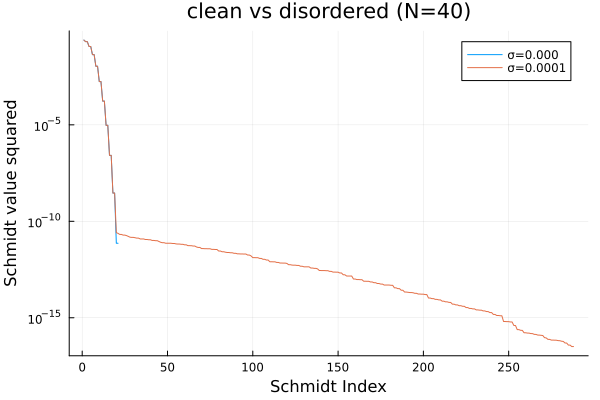

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\clean_vs_disordered_N=40_sigma=0.0001.png"

In [16]:
p_clean_vs_disorder = plot(title="clean vs disordered (N=40)", yscale=:log10, xlabel="Schmidt Index", ylabel="Schmidt value squared")

plot!(p_clean_vs_disorder, 1:length(spec_clean), spec_clean, label="σ=0.000")
plot!(p_clean_vs_disorder, 1:length(spec_disordered), spec_disordered, label="σ=$(run_params_dis["σ"])")

display(p_clean_vs_disorder)
savefig(p_clean_vs_disorder, joinpath(@__DIR__, "images", "clean_vs_disordered_N=40_sigma=$(run_params_dis["σ"]).png"))

In [17]:
ξ = inner(psi_clean, psi_disordered)
psi_r = psi_clean - ξ * psi_disordered
normalize!(psi_r)
spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
println("Sum: $(sum(spec_r))")




Sum: 1.0000000000000022


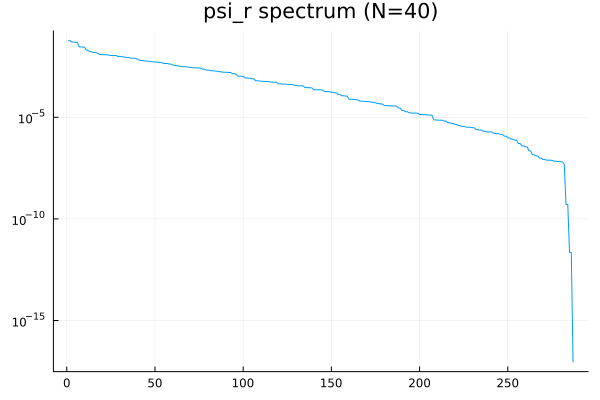

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\psi_r_spectrum_N=40_sigma=0.0001.png"

In [18]:

p3 = plot(1:length(spec_r), spec_r, title="psi_r spectrum (N=40)",yscale=:log10, legend=false)
display(p3)
savefig(p3, joinpath(@__DIR__, "images", "psi_r_spectrum_N=40_sigma=$(run_params_dis["σ"]).png"))

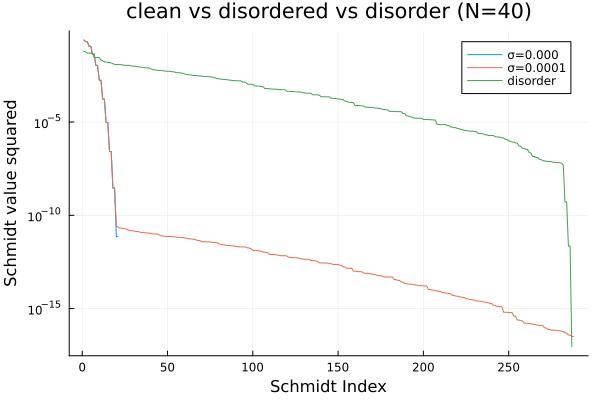

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\clean_vs_disordered_vs_disorder_N=40_sigma=0.0001.png"

In [19]:
p_clean_disordered_disorder = plot(title="clean vs disordered vs disorder (N=40)", yscale=:log10, xlabel="Schmidt Index", ylabel="Schmidt value squared")

plot!(p_clean_disordered_disorder, 1:length(spec_clean), spec_clean, label="σ=0.000")
plot!(p_clean_disordered_disorder, 1:length(spec_disordered), spec_disordered, label="σ=$(run_params_dis["σ"])")
plot!(p_clean_disordered_disorder, 1:length(spec_r), spec_r, label="disorder")

display(p_clean_disordered_disorder)
savefig(p_clean_disordered_disorder, joinpath(@__DIR__, "images", "clean_vs_disordered_vs_disorder_N=40_sigma=$(run_params_dis["σ"]).png"))

In [20]:
sigma_vals = 0.0001:0.00005:0.002
N = 40
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )



current_dir = @__DIR__
base_filepath = extract_filename_from_system_params(system_params)
sigma_to_psi = Dict{Float64, Tuple{MPS, MPS}}()

for sigma in sigma_vals
    println("Processing σ = $sigma")
    run_params_cln = Dict{String, Any}(
        "N" => N,
        "σ" => 0.00
    )

    run_params_dis = Dict{String, Any}(
        "N" => N,
        "σ" => sigma
    )

    MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(sigma)_$base_filepath.hd5")
    matches_clean = find_runs_by_params(MPS_filepath, run_params_cln, load_psi = true, instance_selection =:latest)
    matches_disordered = find_runs_by_params(MPS_filepath, run_params_dis; load_psi = true, instance_selection =:latest)

    sigma_to_psi[sigma] = (matches_clean[1].psi, matches_disordered[1].psi)
end




Processing σ = 0.0001
Processing σ = 0.00015
Processing σ = 0.0002
Processing σ = 0.00025
Processing σ = 0.0003
Processing σ = 0.00035
Processing σ = 0.0004
Processing σ = 0.00045
Processing σ = 0.0005
Processing σ = 0.00055
Processing σ = 0.0006
Processing σ = 0.00065
Processing σ = 0.0007
Processing σ = 0.00075
Processing σ = 0.0008
Processing σ = 0.00085
Processing σ = 0.0009
Processing σ = 0.00095
Processing σ = 0.001
Processing σ = 0.00105
Processing σ = 0.0011
Processing σ = 0.00115
Processing σ = 0.0012
Processing σ = 0.00125
Processing σ = 0.0013
Processing σ = 0.00135
Processing σ = 0.0014
Processing σ = 0.00145
Processing σ = 0.0015
Processing σ = 0.00155
Processing σ = 0.0016
Processing σ = 0.00165
Processing σ = 0.0017
Processing σ = 0.00175
Processing σ = 0.0018
Processing σ = 0.00185
Processing σ = 0.0019
Processing σ = 0.00195
Processing σ = 0.002


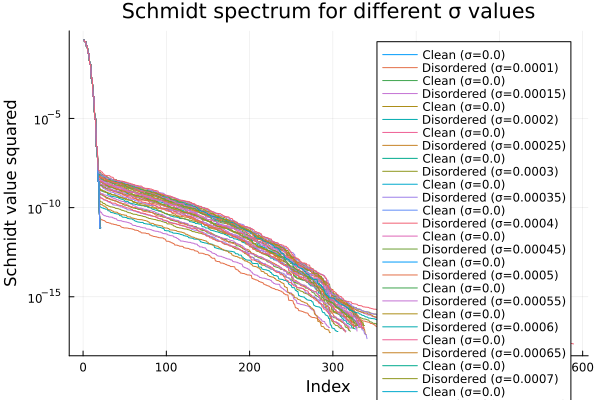

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\schmidt_spectra.png"

In [21]:
sorted_pairs = sort(collect(sigma_to_psi), by = x -> x[1])
p_ss = plot(title="Schmidt spectrum for different σ values", yscale=:log10, xlabel="Index", ylabel="Schmidt value squared")
for (sigma, (psi_cln, psi_dis)) in sorted_pairs
    spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(psi_cln)
    spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(psi_dis)
    plot!(p_ss, spec_cln, label="Clean (σ=0.0)")
    plot!(p_ss, spec_dis, label="Disordered (σ=$(sigma))")
end
display(p_ss)
savefig(p_ss, joinpath(@__DIR__, "images", "schmidt_spectra.png"))

6.148670461669781e-10
1.4542439474851676e-9
2.8518181149905786e-9
3.747941956788736e-9
5.56531676298988e-9
8.646292792846566e-9
9.610545248506241e-9
1.3819958732952387e-8
1.4471908560409474e-8
1.7157083087582237e-8
2.3767225520998636e-8
2.8029648158067744e-8
2.7849452743922143e-8
3.689533312201121e-8
4.3017775674947245e-8
4.97482612882294e-8
5.19208627203227e-8
5.7703654743335164e-8
6.493108717364748e-8
7.16594878991117e-8
8.147273222736118e-8
8.346609869924748e-8
9.356567765017587e-8
1.0831516172871147e-7
1.123451907059092e-7
1.1411329170485374e-7
1.3013713273668515e-7
1.4180107288375154e-7
1.4396478209555141e-7
1.7017423958876066e-7
1.5397922503712635e-7
1.793355315360401e-7
1.7926441553406391e-7
2.0433752423443252e-7
1.9822912755707023e-7
2.0727096727846117e-7
2.3215088584827015e-7
2.3241455737732508e-7
2.6662911789543386e-7


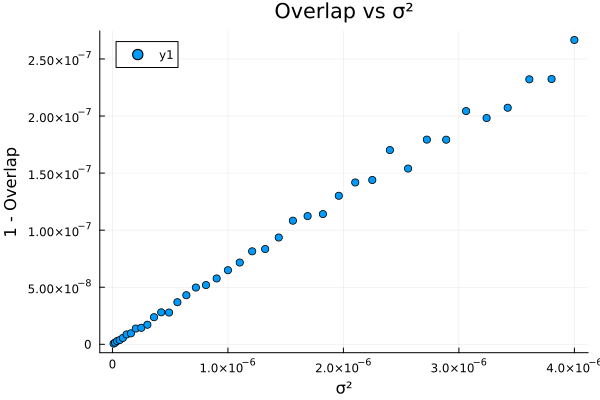

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\overlap_vs_sigma_squared.png"

In [22]:
function overlap(a,b)
    return 1 - abs(inner(a,b)) 
end


overlaps = []
sigmas = []
for (sigma, (psi_cln, psi_dis)) in sorted_pairs
    fid = overlap(psi_cln, psi_dis)
    println(fid)
    push!(sigmas, sigma^2)
    push!(overlaps, fid)
end

p_overlap = scatter(sigmas, overlaps, xlabel="σ²", ylabel="1 - Overlap", title="Overlap vs σ²")
display(p_overlap)
savefig(p_overlap, joinpath(@__DIR__, "images", "overlap_vs_sigma_squared.png"))


Sum for σ=0.0001: 0.9999999999999993
Sum for σ=0.00015: 0.9999999999999999
Sum for σ=0.0002: 0.9999999999999998
Sum for σ=0.00025: 1.0000000000000018
Sum for σ=0.0003: 0.9999999999999996
Sum for σ=0.00035: 1.0000000000000007
Sum for σ=0.0004: 1.0000000000000009
Sum for σ=0.00045: 1.0000000000000007
Sum for σ=0.0005: 1.0000000000000013
Sum for σ=0.00055: 0.9999999999999981
Sum for σ=0.0006: 0.999999999999999
Sum for σ=0.00065: 1.0000000000000007
Sum for σ=0.0007: 0.999999999999998
Sum for σ=0.00075: 0.9999999999999986
Sum for σ=0.0008: 0.999999999999999
Sum for σ=0.00085: 1.0000000000000022
Sum for σ=0.0009: 1.0000000000000013
Sum for σ=0.00095: 0.9999999999999998
Sum for σ=0.001: 0.9999999999999998
Sum for σ=0.00105: 1.0000000000000018
Sum for σ=0.0011: 1.0000000000000016
Sum for σ=0.00115: 0.9999999999999998
Sum for σ=0.0012: 1.0000000000000013
Sum for σ=0.00125: 1.000000000000001
Sum for σ=0.0013: 1.0
Sum for σ=0.00135: 1.0000000000000004
Sum for σ=0.0014: 0.9999999999999997
Sum for 

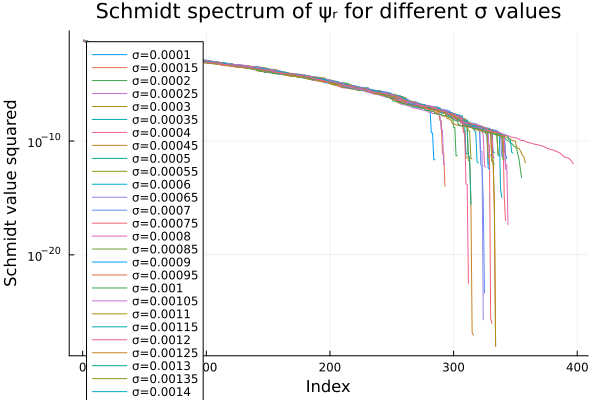

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\psi_r_spectra.png"

In [23]:
function get_psi_r(cln, dis; normalise = true)
    ξ = inner(cln, dis)
    psi_r = dis - ξ * cln
    if normalise
        normalize!(psi_r)
    end
    return psi_r
end

p_psi_r = plot(title="Schmidt spectrum of ψᵣ for different σ values", yscale=:log10, xlabel="Index", ylabel="Schmidt value squared", legend=:topleft)
for (sigma, (psi_cln, psi_dis)) in sorted_pairs
    psi_r = get_psi_r(psi_cln, psi_dis)
    spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
    println("Sum for σ=$(sigma): $(sum(spec_r))")
    plot!(p_psi_r, spec_r, label="σ=$(sigma)")
end
display(p_psi_r)
savefig(p_psi_r, joinpath(@__DIR__, "images", "psi_r_spectra.png"))


In [24]:
# sigmas_to_psis = Dict{Float64, Tuple{Vector{MPS}, Vector{MPS}}}()

# for sigma in sigma_vals
#     run_params_cln = Dict{String, Any}(
#         "N" => N,
#         "σ" => 0.00
#     )

#     run_params_dis = Dict{String, Any}(
#         "N" => N,
#         "σ" => sigma
#     )

#     MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(sigma)_$base_filepath.hd5")
#     matches_clean = find_runs_by_params(MPS_filepath, run_params_cln, load_psi = true, instance_selection =:all)
#     matches_disordered = find_runs_by_params(MPS_filepath, run_params_dis; load_psi = true, instance_selection =:all)

#     clean_psis = [match.psi for match in matches_clean if match.psi !== nothing]  
#     disordered_psis = [match.psi for match in matches_disordered if match.psi !== nothing]  

#     sigmas_to_psis[sigma] = (clean_psis, disordered_psis)
# end

In [25]:
# sorted_pairs_psis = sort(collect(sigmas_to_psis), by = x -> x[1])

# avg_overlaps = []
# err_overlaps = []
# sigma_variances = []

# for (sigma, (clean_psis, disordered_psis)) in sorted_pairs_psis
#     overlaps = [overlap(c, d) for (c, d) in zip(clean_psis, disordered_psis)]
#     avg_o = mean(overlaps)
#     err_o = std(overlaps) / sqrt(length(overlaps))
#     if isnan(err_o)
#         err_o = 0
#     end

#     push!(avg_overlaps, avg_o)
#     push!(err_overlaps, err_o)
#     push!(sigma_variances, sigma^2)

# end

# p_overlap_error = scatter(sigma_variances, avg_overlaps, yerr=err_overlaps, xlabel="σ²", ylabel="1 - Overlap", title="Average Overlap vs σ² with Error Bars")
# display(p_overlap_error)
# savefig(p_overlap_error, joinpath(@__DIR__, "images", "overlap_vs_sigma_squared_with_error_bars.png"))

In [26]:
# using Statistics, GLM, DataFrames


# mask_valid_data = .!(isnan.(sigma_variances) .| isinf.(sigma_variances) .| 
#                      isnan.(avg_fidelities)  .| isinf.(avg_fidelities))

# X_clean = sigma_variances[mask_valid_data]
# Y_clean = avg_fidelities[mask_valid_data]
# err_clean = err_fidelities[mask_valid_data]


# valid_err_indices = (err_clean .> 0) .& .!isnan.(err_clean) .& .!isinf.(err_clean)
# valid_inv_vars = 1.0 ./ (err_clean[valid_err_indices] .^ 2)
# default_weight = isempty(valid_inv_vars) ? 1.0 : median(valid_inv_vars)

# final_weights = zeros(Float64, length(err_clean))
# for i in 1:length(err_clean)
#     e = err_clean[i]
#     # If error is positive, finite, and not NaN, use 1/e^2. Otherwise use default.
#     if !isnan(e) && !isinf(e) && e > 1e-12 # 1e-12 prevents massive weights from tiny errors
#         final_weights[i] = 1.0 / e^2
#     else
#         final_weights[i] = default_weight
#     end
# end

# df = DataFrame(X = X_clean, Y = Y_clean)
# model = lm(@formula(Y ~ 0 + X), df, wts=final_weights)

# gradient = coef(model)[1]
# grad_err = stderror(model)[1]

# println("Gradient: $gradient ± $grad_err")

In [27]:

# N_vals = 20:10:60
# sigma_vals = 0.0001:0.0001:0.002
# accuracies = [10^-16]

# p_master = plot(title="fidelity with variance for different N",
#                 xlabel="var (σ^2)",
#                 ylabel="fidelity (1-ξ)",
#                 legend=:topleft)

# for (i, N) in enumerate(N_vals)
#     @info "Processing N = $N"

#     avg_fids = Float64[]
#     err_fids = Float64[]
#     sig_vars = Float64[]

#     for sigma in sigma_vals
#         system_params = Dict{String,Any}(
#             "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
#             "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
#         )
#         fp_suffix = extract_filename_from_system_params(system_params)
#         fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(sigma)_$(fp_suffix).hd5")

#         cln_rns = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
#         dis_rns = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

#         if !isempty(cln_rns) && !isempty(dis_rns)
#             fids = [fidelity(c.psi, d.psi) for (c, d) in zip(cln_rns, dis_rns)]

#             push!(avg_fids, mean(fids))
#             push!(err_fids, length(fids) > 1 ? sem(fids) : 0.0)
#             push!(sig_vars, sigma^2)
#         end
#     end

#     if length(avg_fids) > 1

#         wts = [e > 0 ? 1/e^2 : 1.0 for e in err_fids]

#         df = DataFrame(X = sig_vars, Y = avg_fids)
#         model = lm(@formula(Y ~ 0 + X), df, wts=wts)

#         gradient = coef(model)[1]
#         grad_err = stderror(model)[1]

#         label_str = "N=$N (m=$(round(gradient, digits=2)) ± $(round(grad_err, digits=2)))"

#         scatter!(p_master, sig_vars, avg_fids, yerror=err_fids, label=false, color=i)

#         plot!(p_master, x -> gradient * x, 0, maximum(sig_vars),
#               label=label_str, lw=2, linestyle=:dash, color=i)
#     end
# end

# display(p_master)
# savefig(p_master, joinpath(@__DIR__, "images", "fidelity_scaling_N_sweep.png"))

# DEVIATION INDEX 

In [28]:
function find_deviation_idx(schmidt_spectrum::Vector{Float64}; window_size=11, poly_order=2)::Int64
    log_spec = log10.(max.(schmidt_spectrum, 1e-18))
    
    # Smooth the data to handle noise in the spectrum
    sg = savitzky_golay(log_spec, window_size, poly_order) 
    smoothed_log_y = sg.y
    x = 1:length(smoothed_log_y)
    
    # Find knees on the smoothed curve
    res = kneedle(x, smoothed_log_y)
    deviation_indices = knees(res)
    
    # Return the first detected index (or handle empty case)
    return isempty(deviation_indices) ? 0 : deviation_indices[1]
end

find_deviation_idx (generic function with 1 method)

In [29]:
N_vals = 20:10:90
sigma_vals = 0.0001:0.0001:0.002

deviation_results = Dict{Float64, Vector{Tuple{Int, Int}}}()

println("Starting processing...")

for σ in sigma_vals
    deviation_results[σ] = []
    for N in N_vals
        run_params = Dict{String, Any}("N" => N, "σ" => σ)
        
        filepath_base = extract_filename_from_system_params(system_params)
        MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(σ)_$filepath_base.hd5")
        
        if isfile(MPS_filepath)
            matches = find_runs_by_params(MPS_filepath, run_params; load_psi = true, instance_selection = :latest)
            
            if !isempty(matches)
                psi = matches[1].psi
                spec = get_squared_sorted_schmidt_spectrum_from_mps(psi)

                dev_idx = find_deviation_idx(spec)
                
                push!(deviation_results[σ], (N, dev_idx))
                println("Processed N=$N, σ=$σ -> Index: $dev_idx")

            end

        end
    end
end



Starting processing...
Processed N=20, σ=0.0001 -> Index: 15
Processed N=30, σ=0.0001 -> Index: 21
Processed N=40, σ=0.0001 -> Index: 24
Processed N=50, σ=0.0001 -> Index: 25
Processed N=60, σ=0.0001 -> Index: 26
Processed N=20, σ=0.0002 -> Index: 15
Processed N=30, σ=0.0002 -> Index: 19
Processed N=40, σ=0.0002 -> Index: 22
Processed N=50, σ=0.0002 -> Index: 25
Processed N=60, σ=0.0002 -> Index: 26
Processed N=20, σ=0.0003 -> Index: 16
Processed N=30, σ=0.0003 -> Index: 19
Processed N=40, σ=0.0003 -> Index: 22
Processed N=50, σ=0.0003 -> Index: 25
Processed N=60, σ=0.0003 -> Index: 26
Processed N=20, σ=0.0004 -> Index: 16
Processed N=30, σ=0.0004 -> Index: 19
Processed N=40, σ=0.0004 -> Index: 22
Processed N=50, σ=0.0004 -> Index: 25
Processed N=60, σ=0.0004 -> Index: 26
Processed N=20, σ=0.0005 -> Index: 15
Processed N=30, σ=0.0005 -> Index: 19
Processed N=40, σ=0.0005 -> Index: 22
Processed N=50, σ=0.0005 -> Index: 25
Processed N=60, σ=0.0005 -> Index: 26
Processed N=20, σ=0.0006 ->

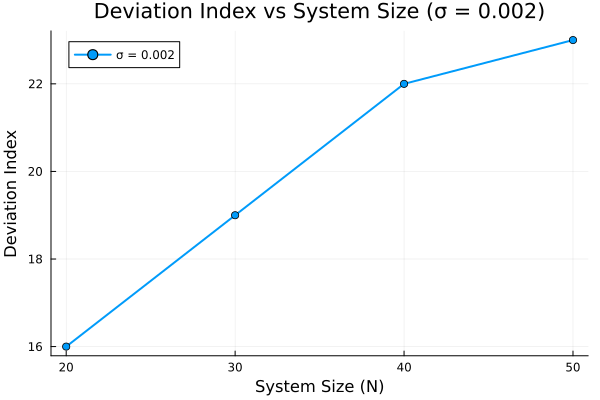

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\deviation_index_vs_N_sigma=0.002.png"

In [30]:

selected_sigma = 0.002

if haskey(deviation_results, selected_sigma) && !isempty(deviation_results[selected_sigma])
    data = deviation_results[selected_sigma]
    sort!(data, by = x -> x[1])
    
    x_vals = [d[1] for d in data]
    y_vals = [d[2] for d in data]
    
      plot(x_vals, y_vals, 
        marker = :circle, 
        title = "Deviation Index vs System Size (σ = $selected_sigma)",
        xlabel = "System Size (N)", 
        ylabel = "Deviation Index",
        label = "σ = $selected_sigma",
        linewidth = 2)
else
    println("No data available to plot for selected σ = $selected_sigma")
end

display(current())
savefig(current(), joinpath(@__DIR__, "images", "deviation_index_vs_N_sigma=$(selected_sigma).png"))

Using deviation index from results: 22


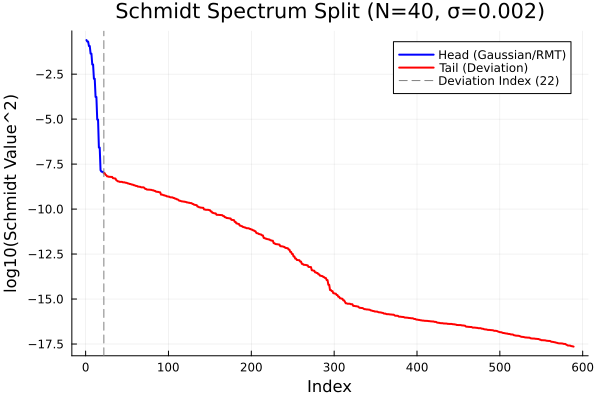

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\schmidt_spectrum_split_N=40_sigma=0.002.png"

In [31]:
selected_sigma = 0.002
selected_N = 40


run_params = Dict{String, Any}("N" => selected_N, "σ" => selected_sigma)
filepath_base = extract_filename_from_system_params(system_params)
MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(selected_sigma)_$filepath_base.hd5")

if isfile(MPS_filepath)
    matches = find_runs_by_params(MPS_filepath, run_params; load_psi = true, instance_selection = :latest)
    
    if !isempty(matches)
        psi = matches[1].psi
        spec = get_squared_sorted_schmidt_spectrum_from_mps(psi)
        
 
        dev_idx = 0
        found_in_results = false
        
        if isdefined(Main, :deviation_results) && haskey(deviation_results, selected_sigma)
            # Search for the tuple with the matching N
            idx_entry = findfirst(x -> x[1] == selected_N, deviation_results[selected_sigma])
            if !isnothing(idx_entry)
                dev_idx = deviation_results[selected_sigma][idx_entry][2]
                found_in_results = true
            end
        end
        
        # Fallback if not found in dictionary
        if dev_idx == 0
            dev_idx = find_deviation_idx(spec)
            println("Calculated deviation index: $dev_idx (fresh calculation)")
        else
            println("Using deviation index from results: $dev_idx")
        end

        # 3. Plotting
        # We plot the log10 of the spectrum for better visibility
        # Adding a small epsilon to avoid log(0)
        y_vals = log10.(max.(spec, 1e-20))
        x_vals = 1:length(spec)

        # Create the base plot
        p = plot(title = "Schmidt Spectrum Split (N=$selected_N, σ=$selected_sigma)",
             xlabel = "Index", 
             ylabel = "log10(Schmidt Value^2)",
             legend = :topright)

        # Plot the "Head" (Blue) -> up to and including the deviation index
        head_range = 1:dev_idx
        plot!(p, x_vals[head_range], y_vals[head_range], 
              color = :blue, 
              linewidth = 2, 
              label = "Head (Gaussian/RMT)")

        # Plot the "Tail" (Red) -> from the deviation index onwards
        # We include the deviation point in the tail too to make the line continuous, 
        # or start from dev_idx + 1. Here we overlap slightly for visual continuity.
        tail_range = dev_idx:length(spec)
        plot!(p, x_vals[tail_range], y_vals[tail_range], 
              color = :red, 
              linewidth = 2, 
              label = "Tail (Deviation)")

        # Vertical Dashed Line
        vline!(p, [dev_idx], 
               linestyle = :dash, 
               color = :grey, 
               label = "Deviation Index ($dev_idx)")

        display(p)
        
    else
        println("No matching run found for N=$selected_N, σ=$selected_sigma")
    end

end

savefig(current(), joinpath(@__DIR__, "images", "schmidt_spectrum_split_N=$(selected_N)_sigma=$(selected_sigma).png"))

In [32]:

selected_sigma = 0.0001
N_vals = 20:10:60

results_head = Int[]
results_tail = Int[]
valid_Ns = Int[]

println("Processing for sigma = $selected_sigma ...")

for N in N_vals
    run_params = Dict{String, Any}("N" => N, "σ" => selected_sigma)
    

    filepath_base = extract_filename_from_system_params(system_params)
    MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(selected_sigma)_$filepath_base.hd5")
    
    if isfile(MPS_filepath)
        matches = find_runs_by_params(MPS_filepath, run_params; load_psi = true, instance_selection = :latest)
        
        if !isempty(matches)
            psi = matches[1].psi
            spec = get_squared_sorted_schmidt_spectrum_from_mps(psi)
            
            # Calculate Deviation Index
            dev_idx = find_deviation_idx(spec)
            
            # Calculate Counts
            head_count = dev_idx
            tail_count = length(spec) - dev_idx
            
            push!(valid_Ns, N)
            push!(results_head, head_count)
            push!(results_tail, tail_count)
            
            println("N=$N: Total=$(length(spec)), Head=$head_count, Tail=$tail_count")
        else
            println("No run found for N=$N")
        end
    else
        println("File not found for N=$N")
    end
end





Processing for sigma = 0.0001 ...
N=20: Total=88, Head=15, Tail=73
N=30: Total=184, Head=21, Tail=163
N=40: Total=288, Head=24, Tail=264
N=50: Total=413, Head=25, Tail=388
N=60: Total=537, Head=26, Tail=511


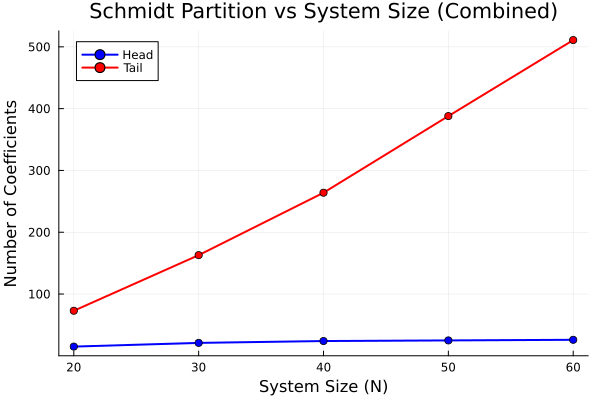

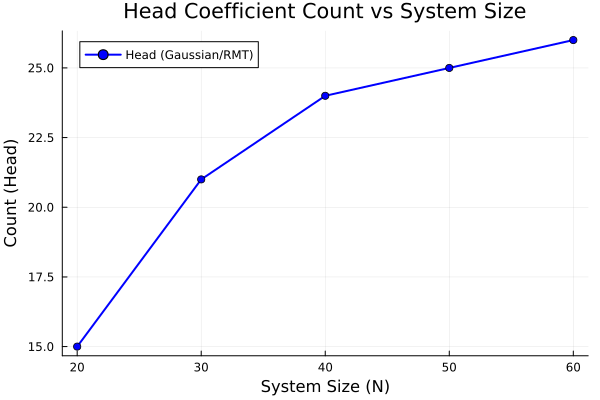

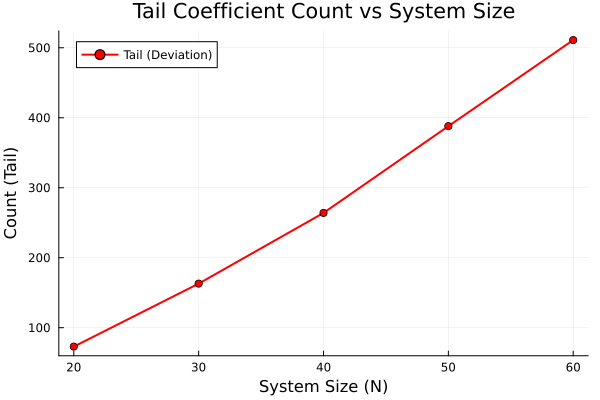

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\schmidt_tail_count_sigma=0.0001.png"

In [33]:

if !isempty(valid_Ns)
    
    p1 = plot(valid_Ns, [results_head results_tail], 
        title = "Schmidt Partition vs System Size (Combined)",
        xlabel = "System Size (N)",
        ylabel = "Number of Coefficients",
        label = ["Head" "Tail"],
        marker = :circle,
        linewidth = 2,
        color = [:blue :red],
        legend = :topleft)
    display(p1)
    savefig(p1, joinpath(@__DIR__, "images", "schmidt_head_tail_count_sigma=$(selected_sigma).png"))

    p2 = plot(valid_Ns, results_head, 
        title = "Head Coefficient Count vs System Size",
        xlabel = "System Size (N)",
        ylabel = "Count (Head)",
        label = "Head (Gaussian/RMT)",
        marker = :circle,
        linewidth = 2,
        color = :blue,
        legend = :topleft)
    display(p2)
    savefig(p2, joinpath(@__DIR__, "images", "schmidt_head_count_sigma=$(selected_sigma).png"))


    p3 = plot(valid_Ns, results_tail, 
        title = "Tail Coefficient Count vs System Size",
        xlabel = "System Size (N)",
        ylabel = "Count (Tail)",
        label = "Tail (Deviation)",
        marker = :circle,
        linewidth = 2,
        color = :red,
        legend = :topleft)
    display(p3)
    savefig(p3, joinpath(@__DIR__, "images", "schmidt_tail_count_sigma=$(selected_sigma).png"))


else
    println("No data available to plot.")
end

In [34]:

selected_sigma = 0.001
N_vals = 20:10:60

weights_head = Float64[]
weights_tail = Float64[]
valid_Ns = Int[]

for N in N_vals
    run_params = Dict{String, Any}("N" => N, "σ" => selected_sigma)
    
    filepath_base = extract_filename_from_system_params(system_params)
    MPS_filepath = joinpath(@__DIR__, "data", "perturb_sigma_$(selected_sigma)_$filepath_base.hd5")
    
    if isfile(MPS_filepath)
        matches = find_runs_by_params(MPS_filepath, run_params; load_psi = true, instance_selection = :latest)
        
        if !isempty(matches)
            psi = matches[1].psi
            spec = get_squared_sorted_schmidt_spectrum_from_mps(psi)
            
            dev_idx = find_deviation_idx(spec)
            

            w_head = sum(spec[1:dev_idx])
            
            if dev_idx < length(spec)
                w_tail = sum(spec[dev_idx+1:end])
            else
                w_tail = 0.0
            end
            
            push!(valid_Ns, N)
            push!(weights_head, w_head)
            push!(weights_tail, w_tail)
            
            println("N=$N: Head Weight=$(round(w_head, digits=4)), Tail Weight=$(round(w_tail, digits=4))")
        else
            println("No run found for N=$N")
        end
    else
        println("File not found for N=$N")
    end
end



N=20: Head Weight=1.0, Tail Weight=0.0
N=30: Head Weight=1.0, Tail Weight=0.0
N=40: Head Weight=1.0, Tail Weight=0.0
N=50: Head Weight=1.0, Tail Weight=0.0
N=60: Head Weight=1.0, Tail Weight=0.0


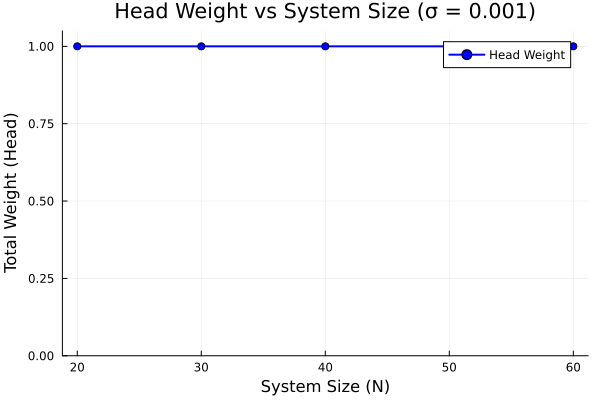

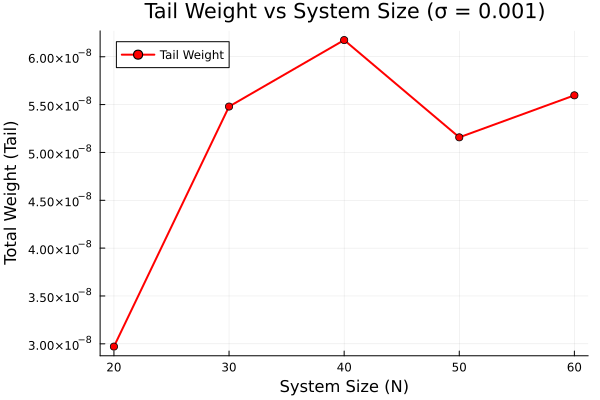

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\schmidt_tail_weight_sigma=0.001.png"

In [35]:

if !isempty(valid_Ns)

    p1 = plot(valid_Ns, weights_head, 
        title = "Head Weight vs System Size (σ = $selected_sigma)",
        xlabel = "System Size (N)",
        ylabel = "Total Weight (Head)",
        label = "Head Weight",
        marker = :circle,
        linewidth = 2,
        color = :blue,
        legend = :topright,
        ylims = (0, 1.05)) # Fixed limit since max probability is 1
    display(p1)
    savefig(p1, joinpath(@__DIR__, "images", "schmidt_head_weight_sigma=$(selected_sigma).png"))


    p2 = plot(valid_Ns, weights_tail, 
        title = "Tail Weight vs System Size (σ = $selected_sigma)",
        xlabel = "System Size (N)",
        ylabel = "Total Weight (Tail)",
        label = "Tail Weight",
        marker = :circle,
        linewidth = 2,
        color = :red,
        legend = :topleft)
    display(p2)
    savefig(p2, joinpath(@__DIR__, "images", "schmidt_tail_weight_sigma=$(selected_sigma).png"))


else
    println("No data available to plot.")
end

# ENTROPIES


In [36]:


# Von Neumann Entropy: S = - sum(p * log(p))
function calc_von_neumann(spectrum::Vector{Float64})
    # Filter out zeros or negatives to avoid domain errors in log
    p = filter(x -> x > 1e-20, spectrum)
    return -sum(p .* log.(p))
end

# Renyi Entropy: S_alpha = (1 / (1-alpha)) * log(sum(p^alpha))
function calc_renyi(spectrum::Vector{Float64}, alpha::Float64)
    p = filter(x -> x > 1e-20, spectrum)
    if alpha == 1.0
        return calc_von_neumann(spectrum)
    else
        return (1 / (1 - alpha)) * log(sum(p .^ alpha))
    end
end

# Hartley Entropy (Alpha = 0): S_0 = log(Rank)
function calc_hartley(spectrum::Vector{Float64}; threshold=1e-12)
    # Count singular values larger than a numerical threshold
    rank = count(x -> x > threshold, spectrum)
    return log(rank)
end


calc_hartley (generic function with 1 method)

In [37]:


system_params = Dict{String,Any}(
    "J" => -1.0,
    "Δ" => -1.0,
    "μ" => 1.0,
    "NUM_SWEEPS" => 10,
    "MAX_BOND_DIM" => 1000,
    "ACC" => 10^-16
)

system_sizes = [20, 30, 40, 50, 60] 
sigma_clean = 0.00
sigma_disordered = 0.0001

base_filename = extract_filename_from_system_params(system_params)
function get_mps_path(sigma_val, base_name)
    return joinpath(@__DIR__, "data", "perturb_sigma_$(sigma_val)_$(base_name).hd5")
end

mps_filepath = get_mps_path(sigma_disordered, base_filename)
println("Reading data from: $mps_filepath")

data_clean = Dict("VN" => Float64[], "Renyi" => Float64[], "Hartley" => Float64[])
data_disordered = Dict("VN" => Float64[], "Renyi" => Float64[], "Hartley" => Float64[])
valid_sizes_clean = Int[]
valid_sizes_dis = Int[]


for N in system_sizes
    # --- Clean Case (sigma = 0.00) ---
    try
        # Note: We search in 'mps_filepath' (the disordered file) for the clean params
        run_params = Dict{String, Any}("N" => N, "σ" => sigma_clean)
        
        matches = find_runs_by_params(mps_filepath, run_params, load_psi = true, instance_selection = :latest)
        
        if !isempty(matches)
            spec = get_squared_sorted_schmidt_spectrum_from_mps(matches[1].psi)
            
            push!(data_clean["VN"], calc_von_neumann(spec))
            push!(data_clean["Renyi"], calc_renyi(spec, 0.5))
            push!(data_clean["Hartley"], calc_hartley(spec))
            push!(valid_sizes_clean, N)
        else
            println("No clean data found for N=$N in $mps_filepath")
        end
    catch e
        println("Error processing clean N=$N: $e")
    end

    # --- Disordered Case (sigma = target) ---
    try
        run_params = Dict{String, Any}("N" => N, "σ" => sigma_disordered)
        
        matches = find_runs_by_params(mps_filepath, run_params, load_psi = true, instance_selection = :latest)
        
        if !isempty(matches)
            spec = get_squared_sorted_schmidt_spectrum_from_mps(matches[1].psi)
            
            push!(data_disordered["VN"], calc_von_neumann(spec))
            push!(data_disordered["Renyi"], calc_renyi(spec, 0.5))
            push!(data_disordered["Hartley"], calc_hartley(spec))
            push!(valid_sizes_dis, N)
        else
            println("No disordered data found for N=$N")
        end
    catch e
        println("Error processing disordered N=$N: $e")
    end
end


Reading data from: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_pertubation\data\perturb_sigma_0.0001_Δ=-1.00e+00_J=-1.00e+00_μ=1.00e+00_MAX_BOND_DIM=1000_NUM_SWEEPS=10_ACC=1.00e-16.hd5


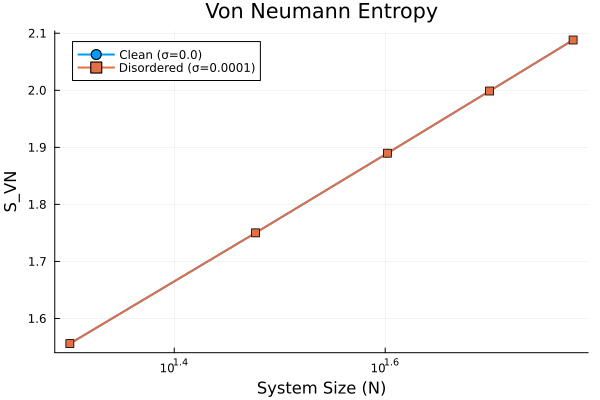

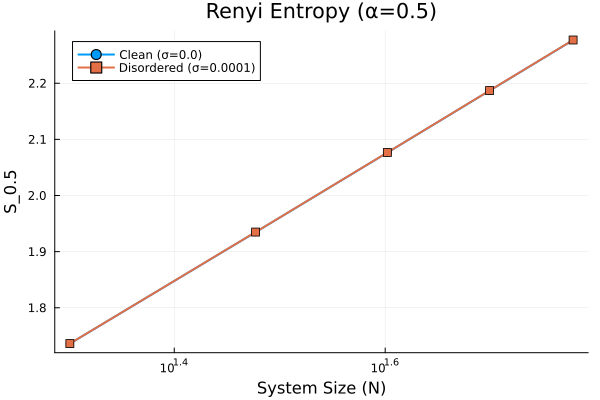

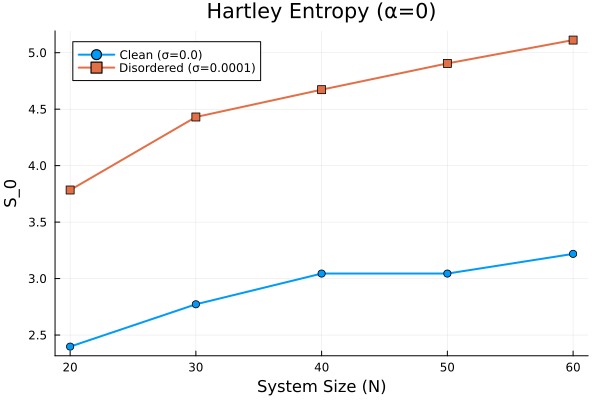

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_pertubation\\images\\hartley_entropy_sigma=0.0001.png"

In [38]:
# Plot 1: Von Neumann Entropy
p1 = plot(valid_sizes_clean, data_clean["VN"], xscale=:log10,
    label="Clean (σ=$sigma_clean)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_VN", title="Von Neumann Entropy")
plot!(p1, valid_sizes_dis, data_disordered["VN"], 
    label="Disordered (σ=$sigma_disordered)", marker=:square, linewidth=2)

# Plot 2: Renyi Entropy (alpha = 0.5)
p2 = plot(valid_sizes_clean, data_clean["Renyi"], xscale=:log10,
    label="Clean (σ=$sigma_clean)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0.5", title="Renyi Entropy (α=0.5)")
plot!(p2, valid_sizes_dis, data_disordered["Renyi"], 
    label="Disordered (σ=$sigma_disordered)", marker=:square, linewidth=2)

# Plot 3: Hartley Entropy (alpha = 0)
p3 = plot(valid_sizes_clean, data_clean["Hartley"], sxscale=:log10,
    label="Clean (σ=$sigma_clean)", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0", title="Hartley Entropy (α=0)")
plot!(p3, valid_sizes_dis, data_disordered["Hartley"], 
    label="Disordered (σ=$sigma_disordered)", marker=:square, linewidth=2)

# Display all plots
display(p1)
display(p2)
display(p3)

savefig(p1, joinpath(@__DIR__, "images", "von_neumann_entropy_sigma=$(sigma_disordered).png"))
savefig(p2, joinpath(@__DIR__, "images", "renyi_entropy_alpha_0.5_sigma=$(sigma_disordered).png"))
savefig(p3, joinpath(@__DIR__, "images", "hartley_entropy_sigma=$(sigma_disordered).png"))

# ENTROPIES OF RESIDUAL STATE

Processed residual state for N=20. Residual norm sum: 1.000000000000003
Processed residual state for N=30. Residual norm sum: 1.0000000000000018
Processed residual state for N=40. Residual norm sum: 1.0000000000000022
Processed residual state for N=50. Residual norm sum: 0.9999999999999993
Processed residual state for N=60. Residual norm sum: 1.0000000000000009


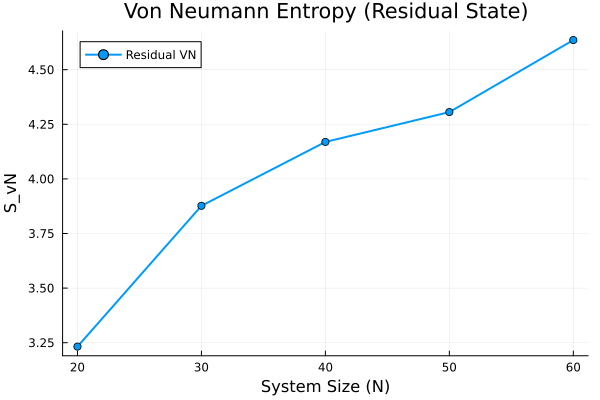

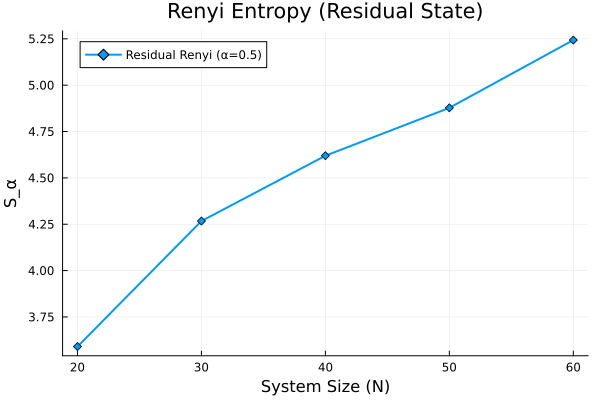

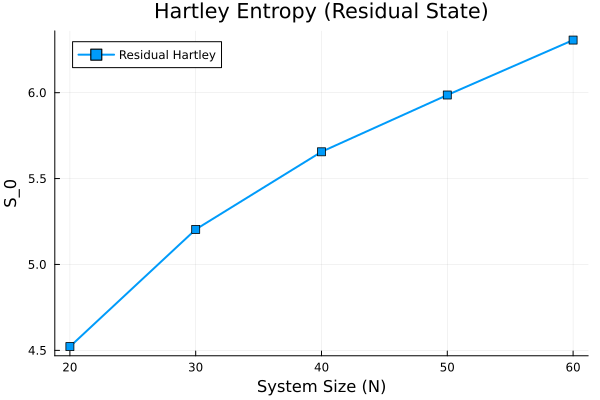

In [39]:

system_sizes = [20, 30, 40, 50, 60] 
sigma_clean = 0.00
sigma_disordered = 0.0001

# Initialize containers for residual state data
data_residual = Dict("VN" => Float64[], "Renyi" => Float64[], "Hartley" => Float64[])
valid_sizes_res = Int[]

for N in system_sizes
    try
        # 1. Load the clean state
        clean_params = Dict{String, Any}("N" => N, "σ" => sigma_clean)
        # Note: assuming clean states are in the same or accessible path
        clean_matches = find_runs_by_params(mps_filepath, clean_params, load_psi = true, instance_selection = :latest)
        
        # 2. Load the disordered state
        dis_params = Dict{String, Any}("N" => N, "σ" => sigma_disordered)
        dis_matches = find_runs_by_params(mps_filepath, dis_params, load_psi = true, instance_selection = :latest)
        
        if !isempty(clean_matches) && !isempty(dis_matches)
            psi_clean = clean_matches[1].psi
            psi_disordered = dis_matches[1].psi
            
            # 3. Calculate the residual state logic
            ξ = inner(psi_clean, psi_disordered)
            psi_r = psi_clean - ξ * psi_disordered
            normalize!(psi_r)
            
            # 4. Get spectrum and calculate entropies
            spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
            
            push!(data_residual["VN"], calc_von_neumann(spec_r))
            push!(data_residual["Renyi"], calc_renyi(spec_r, 0.5))
            push!(data_residual["Hartley"], calc_hartley(spec_r))
            push!(valid_sizes_res, N)
            
            println("Processed residual state for N=$N. Residual norm sum: $(sum(spec_r))")
        else
            println("Missing data for N=$N (Clean: $(!isempty(clean_matches)), Dis: $(!isempty(dis_matches)))")
        end
    catch e
        println("Error processing N=$N: $e")
    end
end

p1 = plot(valid_sizes_res, data_residual["VN"], 
    label="Residual VN", marker=:circle, linewidth=2,
    xlabel="System Size (N)", ylabel="S_vN", title="Von Neumann Entropy (Residual State)")

p2 = plot(valid_sizes_res, data_residual["Renyi"], 
    label="Residual Renyi (α=0.5)", marker=:diamond, linewidth=2,
    xlabel="System Size (N)", ylabel="S_α", title="Renyi Entropy (Residual State)")

p3 = plot(valid_sizes_res, data_residual["Hartley"], 
    label="Residual Hartley", marker=:square, linewidth=2,
    xlabel="System Size (N)", ylabel="S_0", title="Hartley Entropy (Residual State)")

display(p1)
display(p2)
display(p3)